# Real Estate Energy Intensity Estimation & Predictive Modeling

##### Inefficient energy consumption in residential and commercial buildings drives up operational expenditures for both real estate developers and property owners. This project implements an Exploratory Data Analysis (EDA) workflow to uncover the underlying drivers of energy inefficiencies, followed by the development of a robust Supervised Machine Learning pipeline designed to forecast building energy consumption metrics with high predictive accuracy.
##### We will work with a dataset containing features related to the energy consumption of buildings in the United States. We will start by performing an exploratory data analysis, and subsequently train a machine learning model capable of accurately predicting a building's energy expenditure.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.DataFrame(pd.read_csv("data.csv"))
df.head()

,Year_Factor,State_Factor,building_class,facility_type,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,...,days_above_80F,days_above_90F,days_above_100F,days_above_110F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
0,1,State_1,Commercial,Grocery_store_or_food_market,61242.0,1942.0,11.0,2.4,36,50.5,...,14,0,0,0,1.0,1.0,1.0,NaN,248.682615,0
1,1,State_1,Commercial,Warehouse_Distribution_or_Shipping_center,274000.0,1955.0,45.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,26.500150,1
2,1,State_1,Commercial,Retail_Enclosed_mall,280025.0,1951.0,97.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,24.693619,2
3,1,State_1,Commercial,Education_Other_classroom,55325.0,1980.0,46.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,48.406926,3
4,1,State_1,Commercial,Warehouse_Nonrefrigerated,66000.0,1985.0,100.0,2.4,36,50.5,...,14,0,0,0,1.0,1.0,1.0,NaN,3.899395,4


## Exploratory Data Analysis (EDA)

In [3]:
df.describe()

,Year_Factor,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,january_max_temp,february_min_temp,february_avg_temp,...,days_above_80F,days_above_90F,days_above_100F,days_above_110F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
count,75757.000000,7.575700e+04,73920.000000,49048.000000,75757.000000,75757.000000,75757.000000,75757.000000,75757.000000,75757.000000,...,75757.000000,75757.000000,75757.000000,75757.000000,34675.000000,33946.000000,34675.000000,29961.000000,75757.000000,75757.000000
mean,4.367755,1.659839e+05,1952.306764,61.048605,39.506323,11.432343,34.310468,59.054952,11.720567,35.526837,...,82.709809,14.058701,0.279539,0.002442,66.552675,62.779974,4.190601,109.142051,82.584693,37878.000000
std,1.471441,2.468758e+05,37.053619,28.663683,60.656596,9.381027,6.996108,5.355458,12.577272,8.866697,...,25.282913,10.943996,2.252323,0.142140,131.147834,130.308106,6.458789,50.699751,58.255403,21869.306509
min,1.000000,9.430000e+02,0.000000,0.000000,-6.400000,-19.000000,10.806452,42.000000,-13.000000,13.250000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,12.000000,1.001169,0.000000
25%,3.000000,6.237900e+04,1927.000000,40.000000,11.900000,6.000000,29.827586,56.000000,2.000000,31.625000,...,72.000000,6.000000,0.000000,0.000000,1.000000,1.000000,1.000000,88.000000,54.528601,18939.000000
50%,5.000000,9.136700e+04,1951.000000,67.000000,25.000000,11.000000,34.451613,59.000000,9.000000,34.107143,...,84.000000,12.000000,0.000000,0.000000,1.000000,1.000000,1.000000,104.000000,75.293716,37878.000000
75%,6.000000,1.660000e+05,1977.000000,85.000000,42.700000,13.000000,37.322581,62.000000,20.000000,40.879310,...,97.000000,17.000000,0.000000,0.000000,1.000000,1.000000,1.000000,131.000000,97.277534,56817.000000
max,6.000000,6.385382e+06,2015.000000,100.000000,1924.500000,49.000000,64.758065,91.000000,48.000000,65.107143,...,260.000000,185.000000,119.000000,16.000000,360.000000,360.000000,23.300000,311.000000,997.866120,75756.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75757 entries, 0 to 75756
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year_Factor                75757 non-null  int64  
 1   State_Factor               75757 non-null  object 
 2   building_class             75757 non-null  object 
 3   facility_type              75757 non-null  object 
 4   floor_area                 75757 non-null  float64
 5   year_built                 73920 non-null  float64
 6   energy_star_rating         49048 non-null  float64
 7   ELEVATION                  75757 non-null  float64
 8   january_min_temp           75757 non-null  int64  
 9   january_avg_temp           75757 non-null  float64
 10  january_max_temp           75757 non-null  int64  
 11  february_min_temp          75757 non-null  int64  
 12  february_avg_temp          75757 non-null  float64
 13  february_max_temp          75757 non-null  int

We are working with a corpus comprising a total of 75,757 observations across 63 features. The majority of these features correspond to meteorological data, making this domain heavily represented within the dataset. No dimensionality reduction or feature dropping will be performed until we reach the feature engineering phase. It is worth noting the presence of missing values (NaNs) in key target or predictive features, such as the building's energy rating...



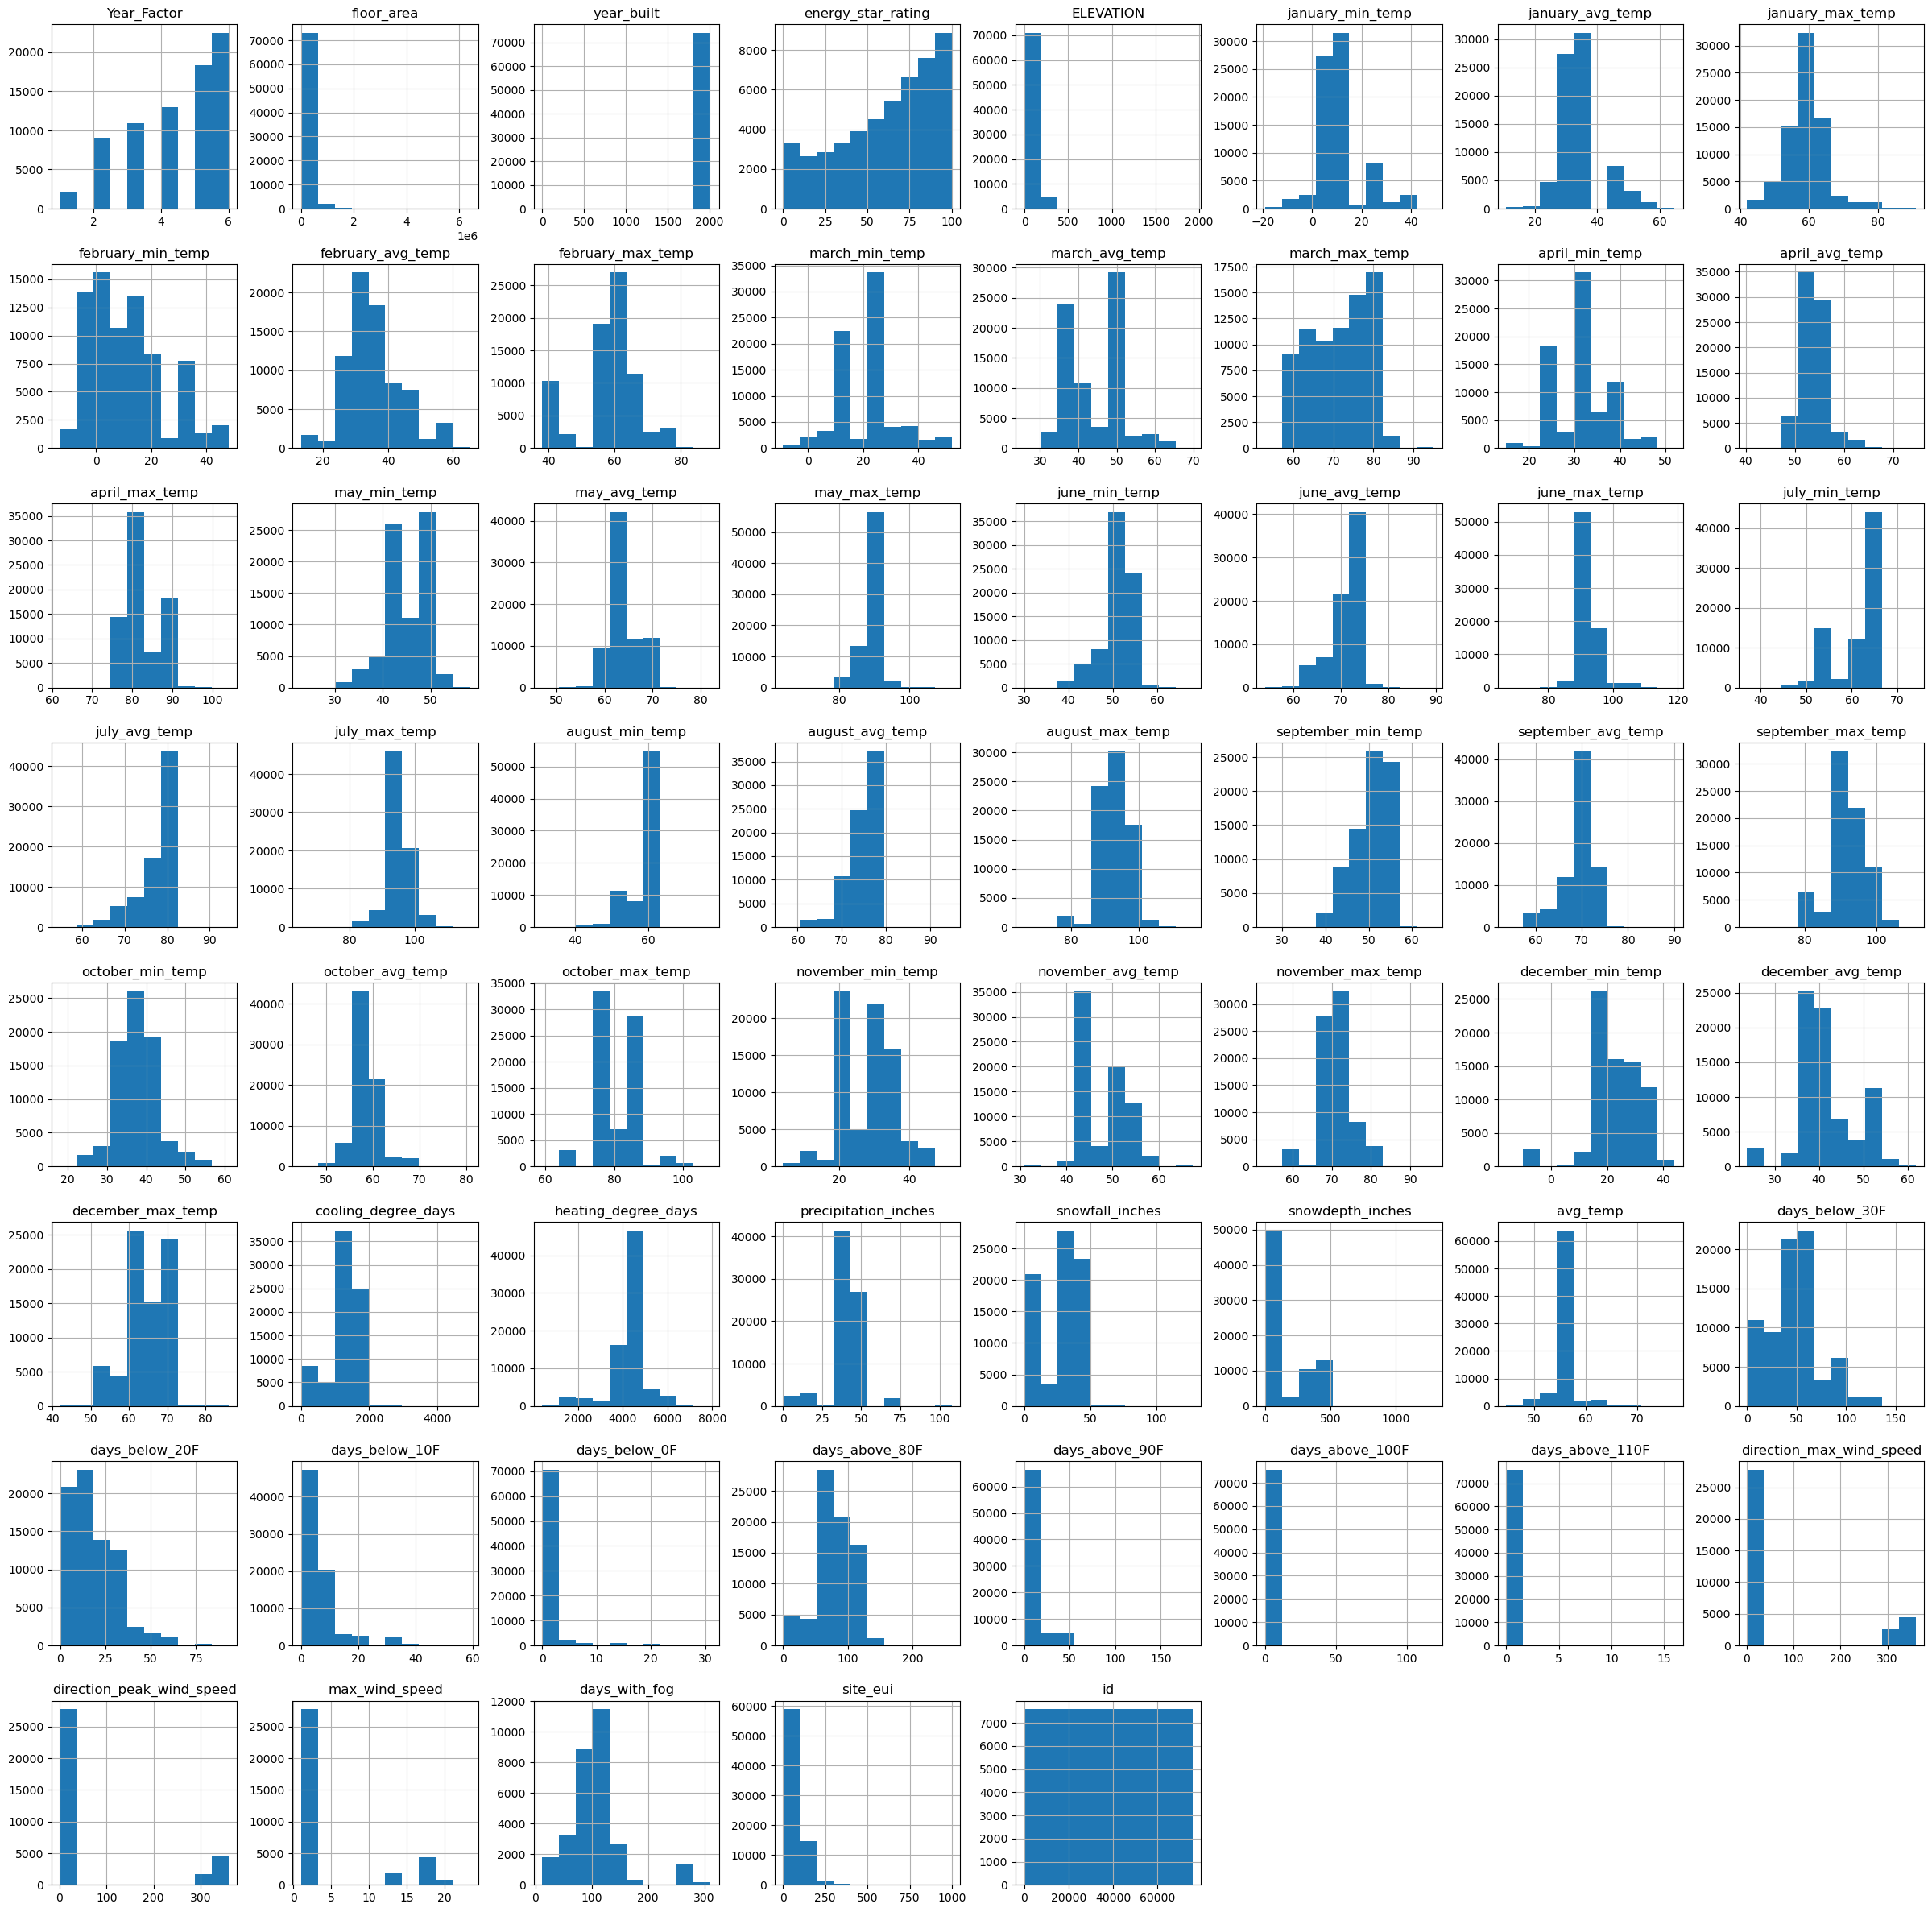

In [5]:
df.hist(figsize = (30, 30))
plt.show()

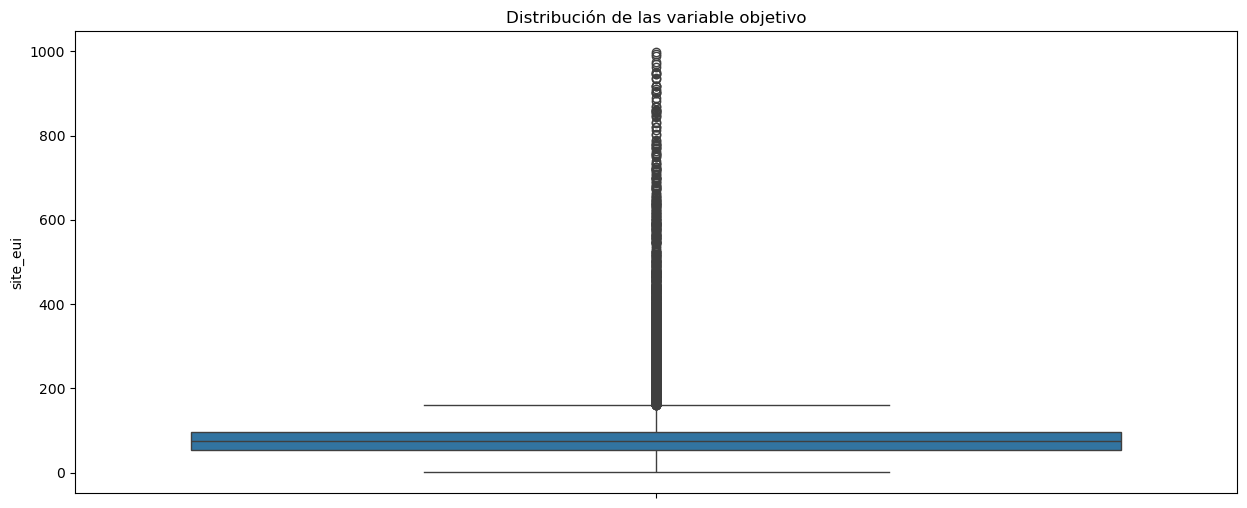

In [6]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df["site_eui"])

plt.title('Distribución de las variable objetivo')
plt.xticks(rotation=45)
plt.show()

{'count': np.int64(75757), 'mean': np.float64(82.5846926362212), 'std': 58.25540265920906, 'min': 1.001169302, '25%': np.float64(54.52860056), 'median': 75.29371585, '75%': np.float64(97.27753425), 'max': 997.8661202, 'skew': np.float64(4.739972264741652)}


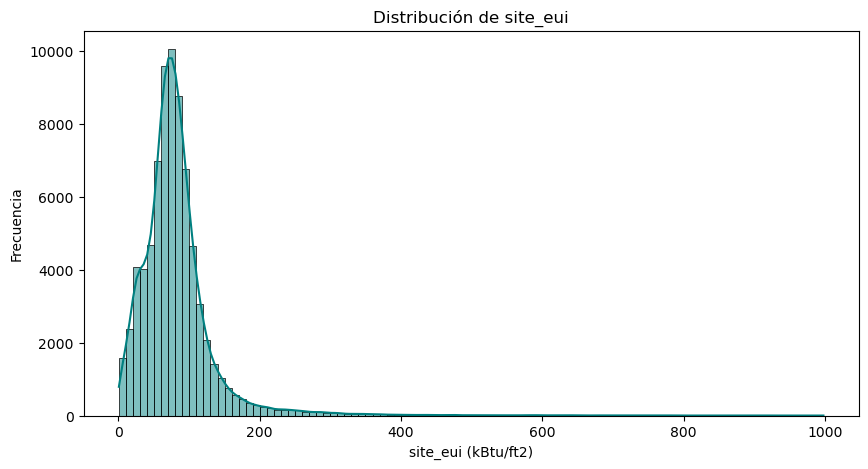

In [7]:
target = df['site_eui']

stats = {
    'count': target.count(),
    'mean': target.mean(),
    'std': target.std(),
    'min': target.min(),
    '25%': target.quantile(0.25),
    'median': target.median(),
    '75%': target.quantile(0.75),
    'max': target.max(),
    'skew': target.skew()
}
print(stats)
plt.figure(figsize=(10, 5))
sns.histplot(target, bins=100, kde=True, color='teal')
plt.title('Distribución de site_eui')
plt.xlabel('site_eui (kBtu/ft2)')
plt.ylabel('Frecuencia')
plt.show()

A high variance and significant skewness are observed in the distribution of the target variable. Later on, we will address this issue by applying a logarithmic transformation.

## Feature Engineering 


One of the features with the lowest rate of missing values is the building's construction year. Given the large volume of available data, we will drop these specific rows since this feature can act as a crucial predictor during model training. Furthermore, we will engineer a new feature representing the building's age, derived from the difference between the data collection year and its construction year.

In [8]:
df = df[(df['year_built'].notna())]

In [9]:
df["building_age"]= 2026 - df["Year_Factor"] -  df["year_built"] 
df = df.drop(columns=["year_built", "Year_Factor"])

We will now address the energy_star_rating feature, which measures the building's energy performance rating. Given that this is a highly relevant predictor with a large proportion of missing values (NA), we cannot simply drop these rows or impute them with the global mean or median of the dataset. By inspecting the data, we observe a clear segmentation between commercial and residential buildings, which points to a potential solution: we will apply conditional imputation by filling the missing values with the median of each respective building type (commercial vs. residential).

In [10]:
df['energy_star_rating'] = df['energy_star_rating'].fillna(
    df.groupby('facility_type')['energy_star_rating'].transform('median')
)

In [11]:
df = df[(df['energy_star_rating'].notna())]

Moving forward, we will drop the building identifier (id column) from the feature space, as it is a non-informative feature and completely irrelevant to the model training process.

In [12]:
df=df.drop(columns=["id"])

In this step, we will encode categorical variables into numerical format to make them compatible with the models.

In [13]:
df['building_class'] = df['building_class'].map({'Commercial': 1, 'Residential': 0})

In [14]:
from category_encoders import TargetEncoder
encoder = TargetEncoder(['facility_type'])
encoder2 = TargetEncoder(["State_Factor"])
df['facility_type'] = encoder.fit_transform(df['facility_type'], df['site_eui'])
df['State_Factor'] = encoder2.fit_transform(df['State_Factor'], df['site_eui'])

Moving forward, we will drop low-variance or low-cardinality features that contain sparse data and lack predictive relevance.

In [15]:
df=df.drop(columns=["direction_max_wind_speed", "direction_peak_wind_speed", "max_wind_speed", "days_with_fog"], axis=1)

Next, we will process the monthly features by aggregating them into seasonal categories. The primary objective is to reduce dimensionality and avoid multicollinearity or feature redundancy within the model.

In [16]:
media_meses_invierno = ['december_avg_temp', 'january_avg_temp', 'february_avg_temp']
max_meses_invierno = ['december_max_temp', 'january_max_temp', 'february_max_temp']
min_meses_invierno = ['december_min_temp', 'january_min_temp', 'february_min_temp']

df["winter_mean"] = df[media_meses_invierno].mean(axis=1)
df["winter_max"] = df[max_meses_invierno].mean(axis=1)
df["winter_min"] = df[min_meses_invierno].mean(axis=1)


media_meses_primavera = ['march_avg_temp', 'april_avg_temp', 'may_avg_temp']
max_meses_primavera = ['march_max_temp', 'april_max_temp', 'may_max_temp']
min_meses_primavera = ['march_min_temp', 'april_min_temp', 'may_min_temp']

df["spring_mean"] = df[media_meses_primavera].mean(axis=1)
df["spring_max"] = df[max_meses_primavera].mean(axis=1)
df["spring_min"] = df[min_meses_primavera].mean(axis=1)


media_meses_verano = ['june_avg_temp', 'july_avg_temp', 'august_avg_temp']
max_meses_verano = ['june_max_temp', 'july_max_temp', 'august_max_temp']
min_meses_verano = ['june_min_temp', 'july_min_temp', 'august_min_temp']

df["summer_mean"] = df[media_meses_verano].mean(axis=1)
df["summer_max"] = df[max_meses_verano].mean(axis=1)
df["summer_min"] = df[min_meses_verano].mean(axis=1)


media_meses_otono = ['september_avg_temp', 'october_avg_temp', 'november_avg_temp']
max_meses_otono = ['september_max_temp', 'october_max_temp', 'november_max_temp']
min_meses_otono = ['september_min_temp', 'october_min_temp', 'november_min_temp']

df["autumn_mean"] = df[media_meses_otono].mean(axis=1)
df["autumn_max"] = df[max_meses_otono].mean(axis=1)
df["autumn_min"] = df[min_meses_otono].mean(axis=1)


columnas_a_borrar = (
    media_meses_invierno + max_meses_invierno + min_meses_invierno +
    media_meses_primavera + max_meses_primavera + min_meses_primavera +
    media_meses_verano + max_meses_verano + min_meses_verano +
    media_meses_otono + max_meses_otono + min_meses_otono
)

df = df.drop(columns=columnas_a_borrar)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72837 entries, 0 to 75756
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State_Factor          72837 non-null  float64
 1   building_class        72837 non-null  int64  
 2   facility_type         72837 non-null  float64
 3   floor_area            72837 non-null  float64
 4   energy_star_rating    72837 non-null  float64
 5   ELEVATION             72837 non-null  float64
 6   cooling_degree_days   72837 non-null  int64  
 7   heating_degree_days   72837 non-null  int64  
 8   precipitation_inches  72837 non-null  float64
 9   snowfall_inches       72837 non-null  float64
 10  snowdepth_inches      72837 non-null  int64  
 11  avg_temp              72837 non-null  float64
 12  days_below_30F        72837 non-null  int64  
 13  days_below_20F        72837 non-null  int64  
 14  days_below_10F        72837 non-null  int64  
 15  days_below_0F         72

# MODELING

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df.drop(columns=['site_eui'])
y = df['site_eui']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_model = HistGradientBoostingRegressor(random_state=42)

model_transformed = TransformedTargetRegressor(
    regressor=base_model,
    func=np.log1p,
    inverse_func=np.expm1
)

model_transformed.fit(X_train, y_train)

y_pred = model_transformed.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- METRICS ---")
print(f"RMSE: {rmse:.2f} kBtu/ft²")
print(f"MAE:  {mae:.2f} kBtu/ft²")
print(f"R²:   {r2:.4f}")

--- METRICS ---
RMSE: 42.13 kBtu/ft²
MAE:  20.65 kBtu/ft²
R²:   0.4476
